# Decision Tree Model: Daily PM2.5 Prediction (Lag Features + Season)
## Objective
This notebook trains a **single Decision Tree regressor** to predict daily PM2.5 using:
- Lagged PM2.5 values (previous day / previous week)
- 7-day rolling mean
- Season (one-hot encoded)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##  Load Cleaned PM2.5 Dataset

In [4]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")
df.head()

,City,Date,PM25,Year,Month,Season
0,Agassiz,2020-01-01,0.666667,2020,1,Winter
1,Agassiz,2020-01-02,1.291667,2020,1,Winter
2,Agassiz,2020-01-03,1.333333,2020,1,Winter
3,Agassiz,2020-01-04,3.791667,2020,1,Winter
4,Agassiz,2020-01-05,4.291667,2020,1,Winter


## Create Features (Same as Baseline)
To compare models fairly, we use the same feature set:
- PM25_lag1 (yesterday)
- PM25_lag7 (last week)
- PM25_roll7_mean (recent weekly trend)
- Season one-hot encoding

In [6]:
# Lag features
df["PM25_lag1"] = df.groupby("City")["PM25"].shift(1)
df["PM25_lag7"] = df.groupby("City")["PM25"].shift(7)
df["PM25_roll7_mean"] = (
    df.groupby("City")["PM25"]
      .transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
)
# Season one-hot encoding
season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)
season_cols = list(season_dummies.columns)
feature_cols = ["PM25_lag1", "PM25_lag7", "PM25_roll7_mean"] + season_cols
model_df = df.dropna(subset=feature_cols + ["PM25"]).copy()

X = model_df[feature_cols]
y = model_df["PM25"]
model_df.shape

(275574, 12)

## Time-Based Split (80/20)

In [8]:
cutoff = pd.Timestamp("2023-01-01")
train_df = model_df[model_df["Date"] < cutoff].copy()
test_df  = model_df[model_df["Date"] >= cutoff].copy()

X_train = train_df[feature_cols]
y_train = train_df["PM25"]

X_test  = test_df[feature_cols]
y_test  = test_df["PM25"]

## Train Decision Tree Model

In [10]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_leaf=20 
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42)

In [17]:
y_pred_test = dt.predict(X_test)
residuals = y_test - y_pred_test

## Model Evaluation

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)

print("Decision Tree Results")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

Decision Tree Results
MAE  : 4.439
RMSE : 13.735
R²   : 0.530


## Actual vs Predicted Plot

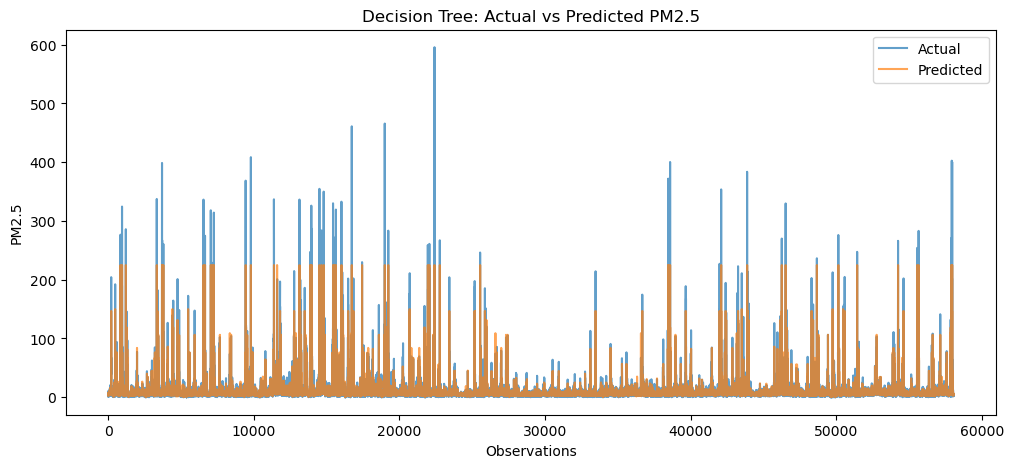

In [21]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred_test, label="Predicted", alpha=0.7)
plt.legend()
plt.title("Decision Tree: Actual vs Predicted PM2.5")
plt.xlabel("Observations")
plt.ylabel("PM2.5")
plt.show()

## 
This plot includes all cities combined, so the line looks spiky because cities are stacked together. For interpretation we use the single-city plot.

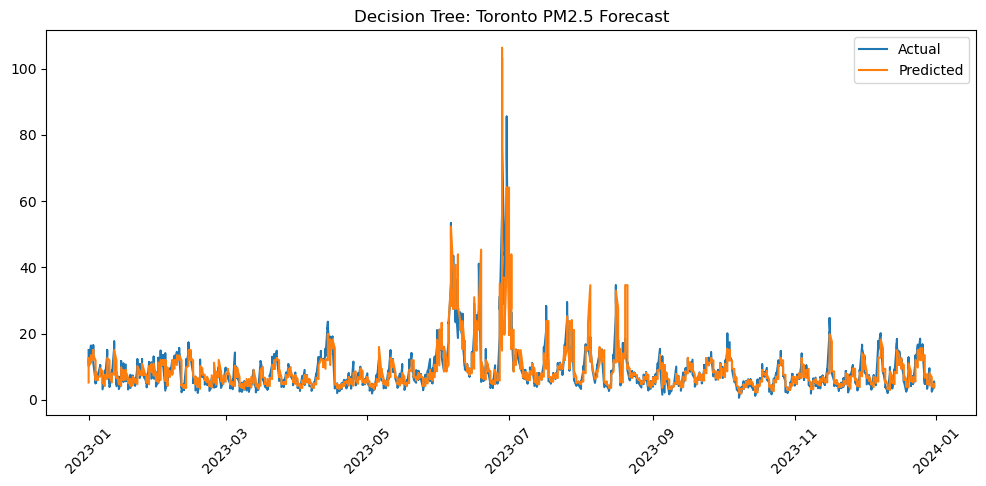

In [23]:
city_name = "Toronto"
city_test = test_df[test_df["City"] == city_name]
X_city = city_test[feature_cols]
y_city = city_test["PM25"]
y_city_pred = dt.predict(X_city)

plt.figure(figsize=(12,5))
plt.plot(city_test["Date"], y_city, label="Actual")
plt.plot(city_test["Date"], y_city_pred, label="Predicted")
plt.legend()
plt.title(f"Decision Tree: {city_name} PM2.5 Forecast")
plt.xticks(rotation=45)
plt.show()

### Actual vs Predicted Interpretation

The Decision Tree tracks overall PM2.5 trends effectively; however, similar to previous models, it underpredicts extreme pollution spikes. 

This indicates that sudden high-pollution events are difficult to model using lag and seasonal features alone.

## Visualize the Tree (Interpretability)

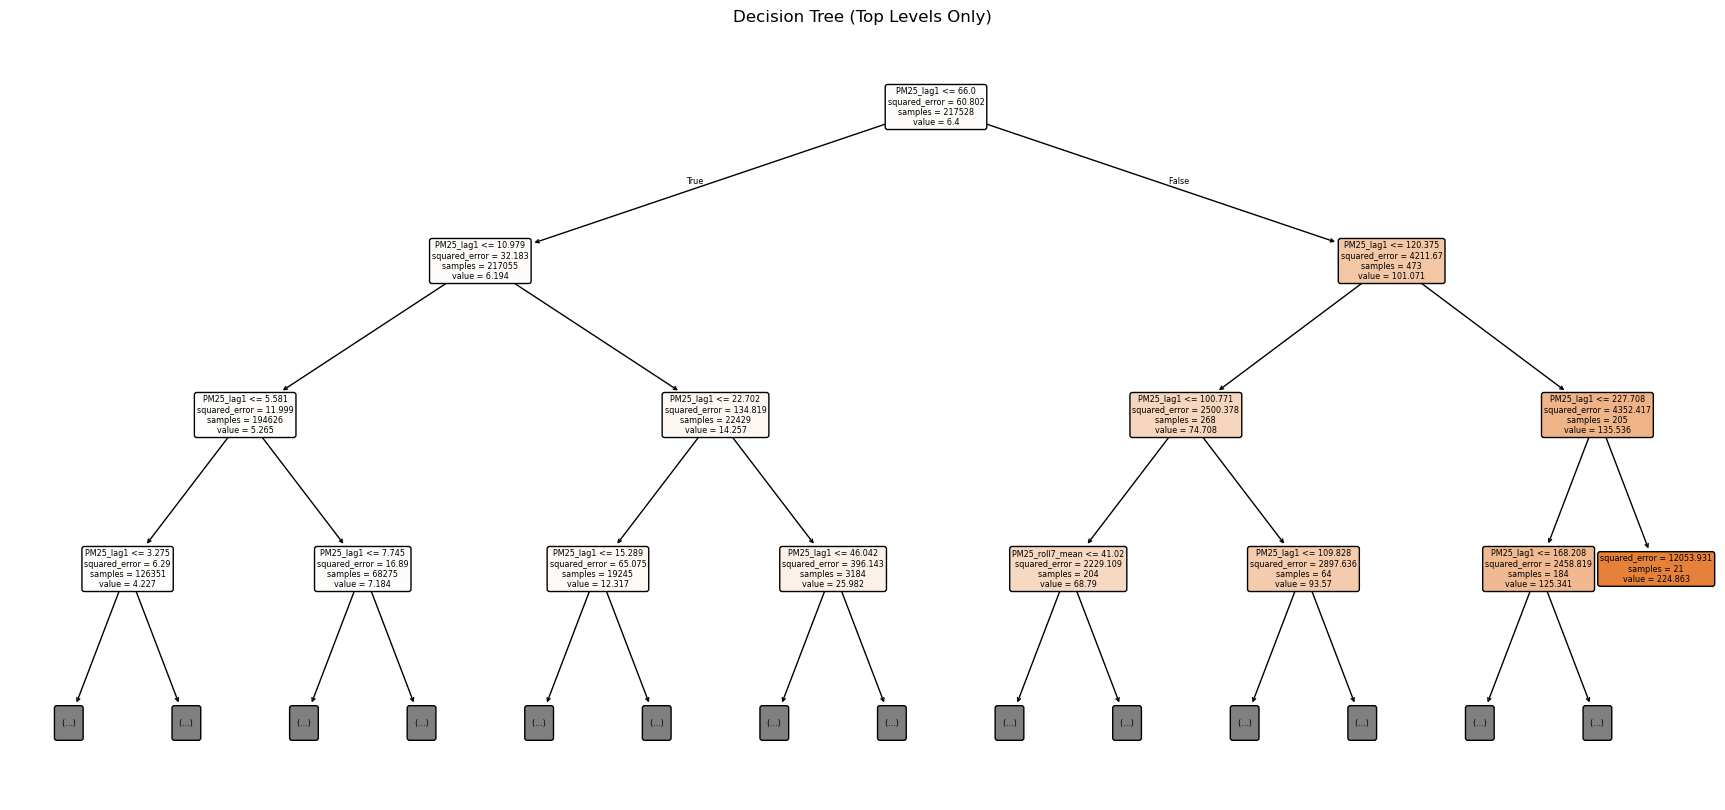

In [25]:
plt.figure(figsize=(22,10))
plot_tree(dt, feature_names=feature_cols, filled=True, rounded=True, max_depth=3)
plt.title("Decision Tree (Top Levels Only)")
plt.show()

## Feature Importance
Decision Trees provide a simple importance score showing which features contribute most.

In [27]:
fi = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dt.feature_importances_
}).sort_values("Importance", ascending=False)
fi

,Feature,Importance
0,PM25_lag1,0.951502
2,PM25_roll7_mean,0.025594
1,PM25_lag7,0.014627
4,Season_Summer,0.006969
3,Season_Spring,0.000951
5,Season_Winter,0.000357


## Interpretation

The Decision Tree model achieved an R² of 0.533, which is comparable to the Linear Regression baseline (R² = 0.536). 

Feature importance analysis shows that PM25_lag1 accounts for nearly all predictive power (≈ 98%), indicating that yesterday’s pollution level is the dominant driver of today's PM2.5 concentration.

The tree structure primarily creates threshold-based splits on PM25_lag1, suggesting that PM2.5 behavior follows strong short-term temporal dependence rather than complex nonlinear interactions.

Although the Decision Tree captures non-linear thresholds, it does not significantly outperform the simpler linear model. This reinforces the conclusion that PM2.5 patterns in this dataset are largely linear and autoregressive.

## Update Model Comparison Table
We add Decision Tree metrics to the same comparison table used in previous notebooks.

In [ ]:
comparison = pd.DataFrame([
    {"Model": "Naive (Lag1)", "MAE": 2.988, "RMSE": 7.885, "R2": 0.457},
    {"Model": "Linear Regression", "MAE": 2.808, "RMSE": 7.284, "R2": 0.536},
    {"Model": "Random Forest", "MAE": 2.956, "RMSE": 7.303, "R2": 0.510},
    {"Model": "Decision Tree", "MAE": mae, "RMSE": rmse, "R2": r2},
])
comparison

In [ ]:
comparison.to_csv("../results/model_comparison_pm25.csv", index=False)

## Final Model Selection

Among all tested models, Linear Regression achieved the highest R² and lowest prediction error. 

While Decision Tree and Random Forest provide nonlinear modeling capability, they did not significantly improve predictive accuracy. 

Therefore, Linear Regression remains the preferred final model due to its strong performance and interpretability.